In [1]:
import sys,os
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from GaussianProcess.engine import GPCalculator

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# 1) Create data

## Settings

In [2]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

x_label = r'$x$'
y_label = r'$f(x)$'

In [3]:
from parametric_approach.polynomial import PolynomialFit
theory = PolynomialFit(None,None,order=3)
theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

## Data generation

In [4]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

## Plot data

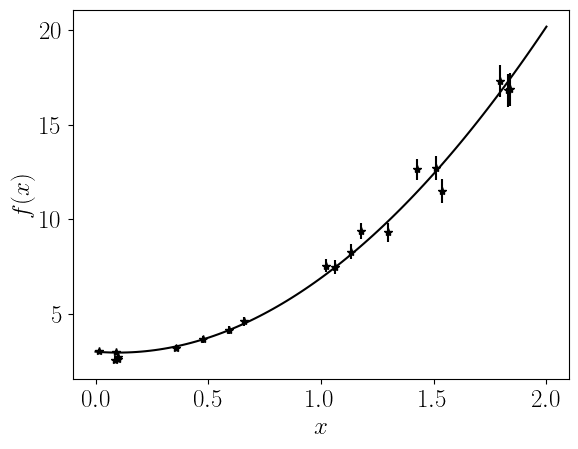

In [5]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# 2) Observable reconstruction

## Settings

In [6]:
N_recon = 5
xmin_recon = 0.1
xmax_recon = 1.8
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

possible_derivatives = ['f','int','d1','d2']

kernel = 'RBF'

#methods = ['MAP']
methods = ['BAYESIAN','MAP']
colors  = [red,yellow]

## Perform reconstruction

In [7]:
gp = GPCalculator(dataset,covmat,kernel_type=kernel)

In [8]:
covmats = []
meandf = []
for method in methods:
    tini = time()
    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)
    means['Method'] = method
    covmats.append(joint_cov)
    meandf.append(means)

    print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

allmeans = pd.concat(meandf,ignore_index=True)

Removed no burn in
GP (BAYESIAN) done in 255.67 s
GP (MAP) done in 3.07 s


## Plot reconstruction

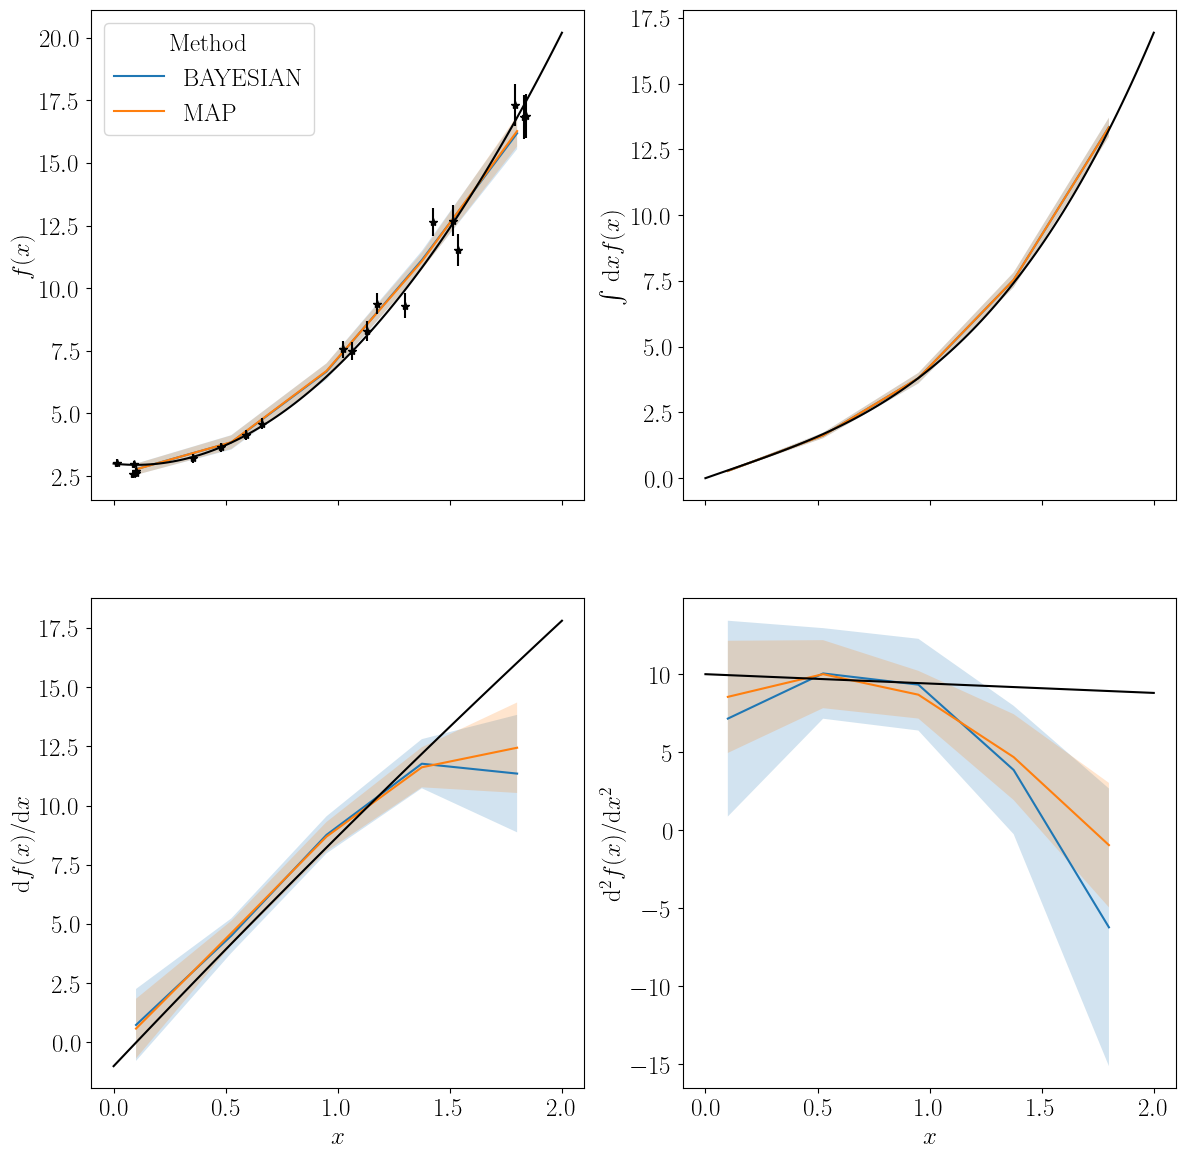

In [9]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in methods:
        df = allmeans[allmeans['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method')
    else:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method',legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# 3) Obtain derived function

$$D(x)=f'(x)/f(x)$$

In [10]:
needed = ['f','d1']

In [11]:
from Reconstruction.reconstructor import DerivedFunction


## Run reconstruction

In [12]:
results = {}
for ind,method in enumerate(methods):

    df = allmeans[allmeans['Method']==method].reset_index(drop=True)
    joint_cov = covmats[ind]

    reconstructor = DerivedFunction(df,joint_cov,sampler='Nautilus',run_options='poor',chatty=True)

    derived_logic = lambda f,d1: d1/f
    derived_name  = 'D'
    
    results[method] = {'sample': reconstructor.run(derived_logic,derived_name,sigma_width=3),
                       'color': colors[ind]}

Detected required variables for derived function: ['f', 'd1']
Starting sampler for 10 parameters...
Loaded prior into Nautilus with dimension 10
Prior keys:  ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'd1_0', 'd1_1', 'd1_2', 'd1_3', 'd1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 2        | 25280    | N/A    | 10059 | -23.21   
NAUTILUS SAMPLING FINISHED
Removed no burn in
Detected required variables for derived function: ['f', 'd1']
Starting sampler for 10 parameters...
Loaded prior into Nautilus with dimension 10
Prior keys:  ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'd1_0', 'd1_1', 'd1_2', 'd1_3', 'd1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | l

## Plotting parameters

### Primary

In [13]:
fiducial_primary = {'f_{}'.format(ind): theory_model(x)['f'] for ind,x in enumerate(x_recon)}
fiducial_primary = fiducial_primary | {'d1_{}'.format(ind): theory_model(x)['d1'] for ind,x in enumerate(x_recon)}

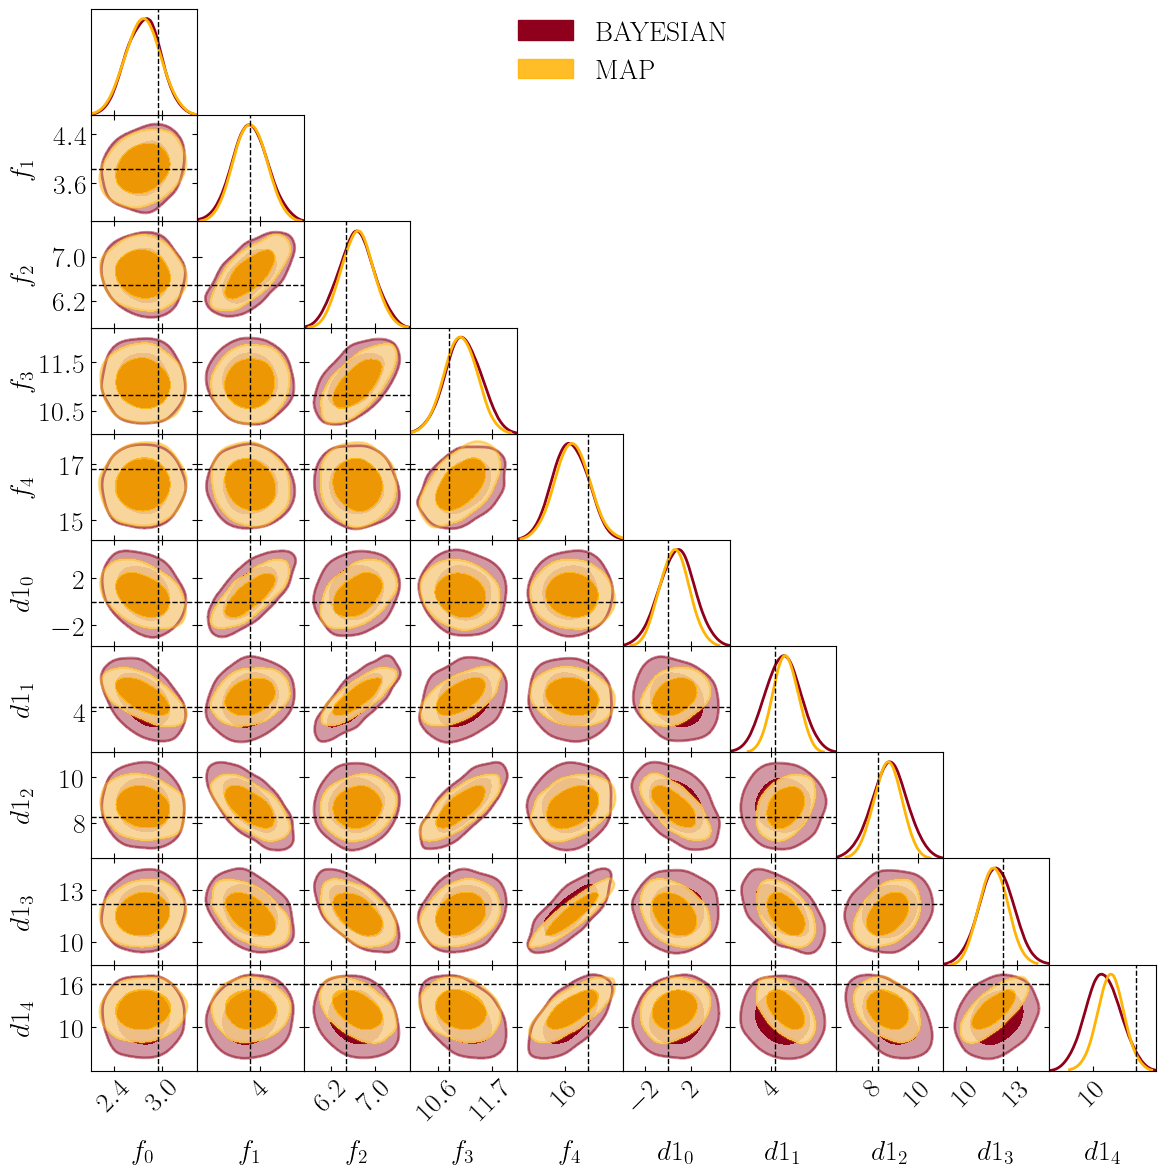

In [14]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_primary.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_primary
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Derived

In [15]:
fiducial_recon = {'D_{}'.format(ind): theory_model(x_recon[ind])['d1']/theory_model(x_recon[ind])['f'] 
                  for ind in range(N_recon)}

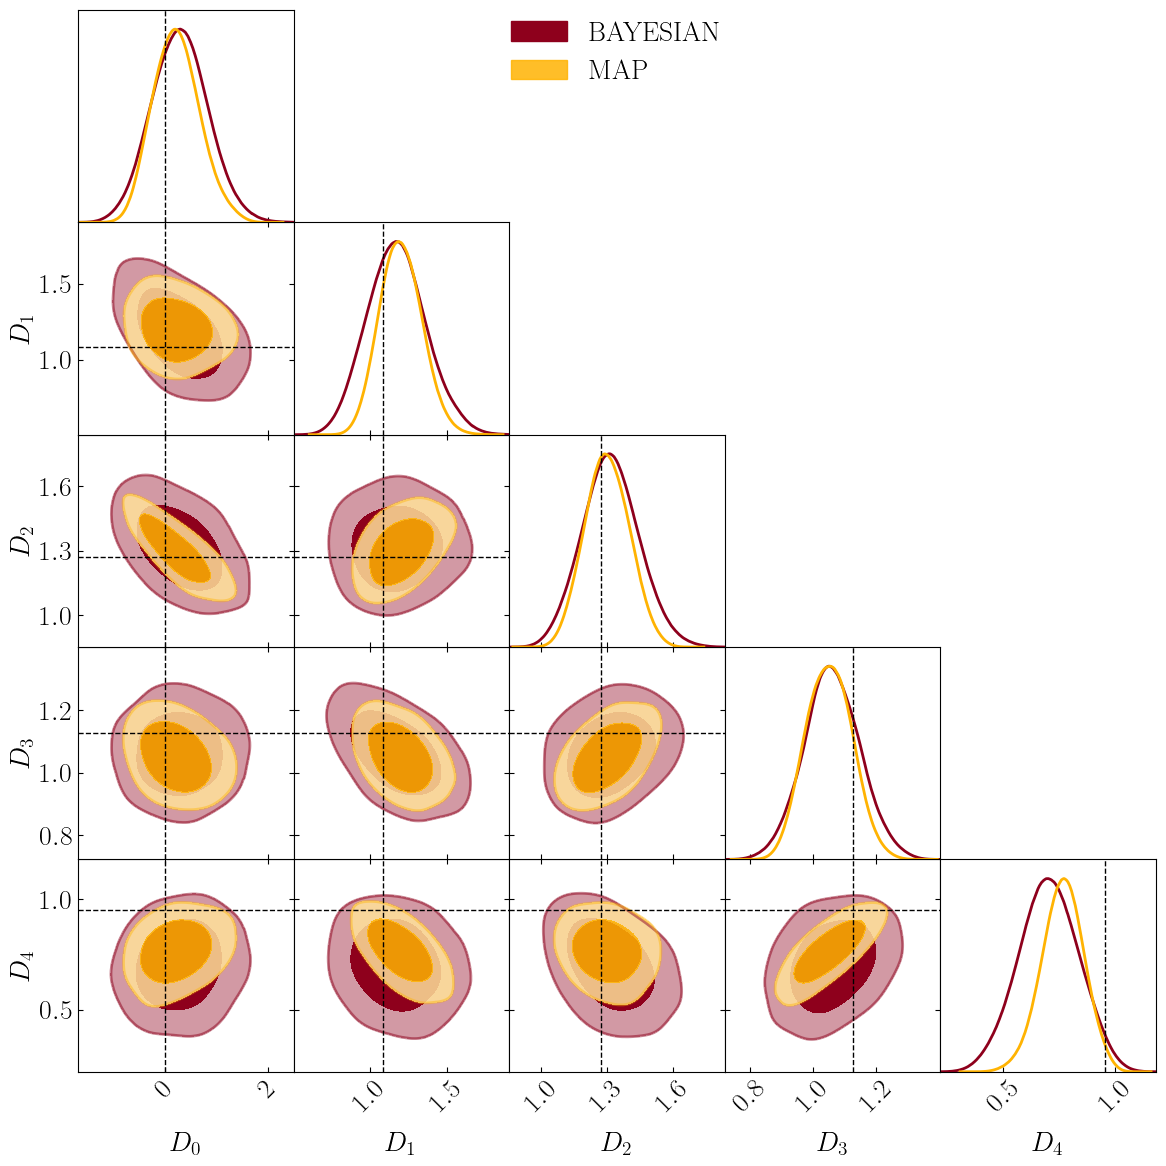

In [16]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

## Plotting reconstructed function

In [17]:
for method in methods:
    sample = results[method]['sample']
    results[method]['reconstruction'] = pd.DataFrame({'x': x_recon})
    results[method]['reconstruction']['value'] = sample.getMeans()[2*N_recon:]
    results[method]['reconstruction']['error'] = np.sqrt(sample.getVars()[2*N_recon:])

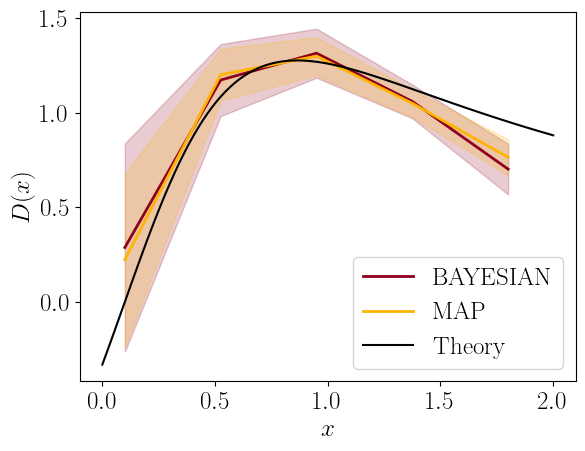

In [18]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in methods:
    reconstruction = results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
plt.plot(xplot,theory_model(xplot)['d1']/theory_model(xplot)['f'],color='black',label='Theory')
plt.xlabel(x_label)
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');